In [1]:
pip install cvxpy scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install osqp


Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import cvxpy as cp

Epoch 0: Primal=0.0306, ||w_avg||=30.3760
Epoch 0: Primal=461.3511, ||w_avg||=30.3760
Epoch 1: Primal=461.3511, ||w_avg||=65.2445
Epoch 1: Primal=2128.4235, ||w_avg||=65.2445
Epoch 2: Primal=2128.4235, ||w_avg||=90.2978
Epoch 2: Primal=4076.8431, ||w_avg||=90.2978
Epoch 3: Primal=4076.8431, ||w_avg||=80.3063
Epoch 3: Primal=3224.5479, ||w_avg||=80.3063
Test Accuracy: 0.9963


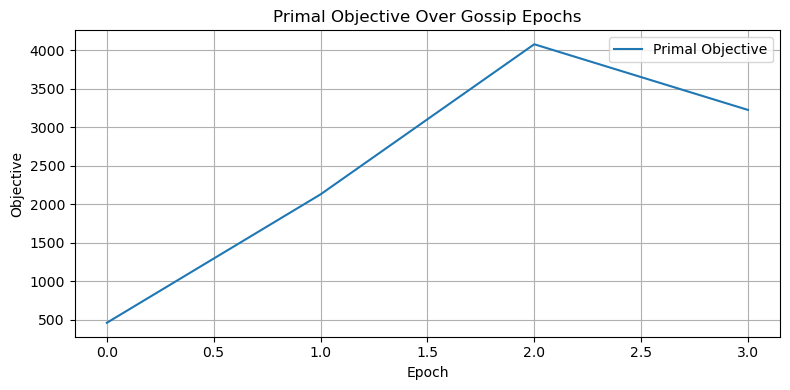

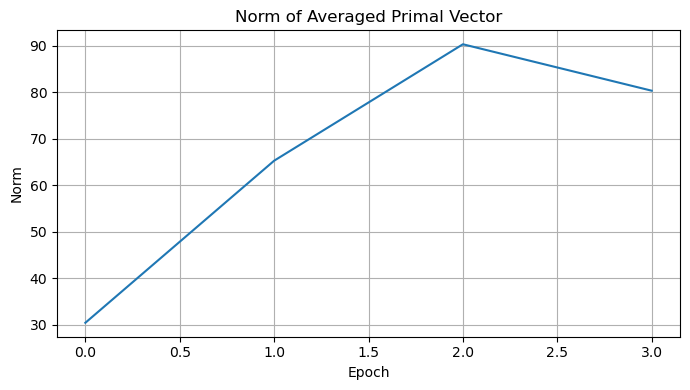

In [9]:
# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Dual solver using CVXPY (local QP)
def solve_dual_local(X, y, C=1.0):
    """
    Solves the dual SVM QP problem locally on (X, y) using CVXPY.
    Returns the optimal alpha vector.
    """
    n = X.shape[0]
    alpha = cp.Variable(n)

    # Compute the Gram matrix (kernel matrix) - linear kernel
    K = X @ X.T
    K = (K + K.T) / 2  # Force symmetry
    Y = np.diag(y)
    Q = Y @ K @ Y      # Equivalent to np.outer(y, y) * K but cleaner

    # Force PSD to avoid numerical issues
    Q_psd = cp.psd_wrap(Q)

    # Define the dual objective
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]

    # Solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    return alpha.value

# 5. Convert alpha to primal vector
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip ring
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

# Initialize persistent alphas
alphas = [np.zeros(len(y_parts[i])) for i in range(num_nodes)]
C = 1.0
lr = 0.01

for epoch in range(epochs):
    for i in range(num_nodes):
        X_i, y_i = X_parts[i], y_parts[i]
        alpha = alphas[i]
        K = X_i @ X_i.T
        for j in range(len(alpha)):
            grad = 1 - y_i[j] * np.sum(alpha * y_i * K[:, j])
            alpha[j] += lr * grad
            alpha[j] = np.clip(alpha[j], 0, C)
        alphas[i] = alpha
        w_nodes[i] = alpha_to_primal(alpha, X_i, y_i)

    # Gossip
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

    # Evaluate primal objective
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")
    
# 8. Evaluate test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plot
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Primal=0.0306, ||w_avg||=0.2474
Epoch 1: Primal=0.0306, ||w_avg||=0.2474
Epoch 2: Primal=0.0306, ||w_avg||=0.2474
Epoch 3: Primal=0.0306, ||w_avg||=0.2474
Test Accuracy: 0.9993


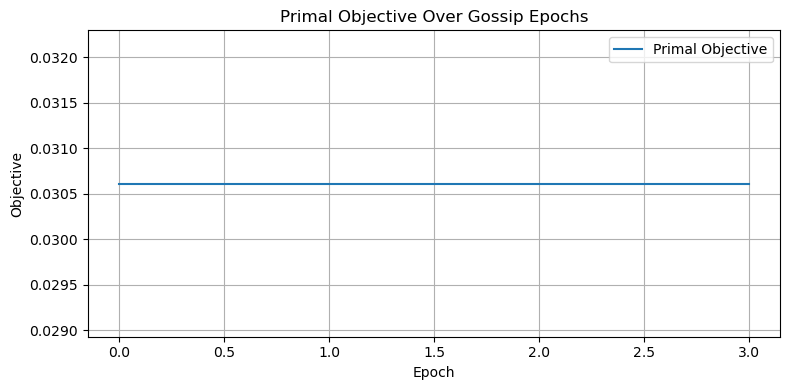

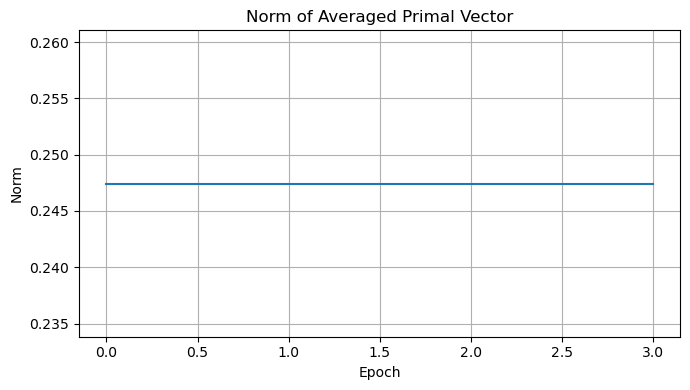

In [10]:

# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert labels from {0, 1} to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split data among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Dual solver using CVXPY (solves local SVM dual)
def solve_dual_local(X, y, C=1.0):
    n = X.shape[0]
    alpha = cp.Variable(n)

    K = X @ X.T
    K = (K + K.T) / 2  # Ensure symmetry
    Q = np.outer(y, y) * K

    Q_psd = cp.psd_wrap(Q)
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)
 
    return alpha.value

# 5. Convert alpha to primal vector (linear kernel)
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip ring averaging
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop using CVXPY dual solver per node
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

for epoch in range(epochs):
    alphas = []
    for i in range(num_nodes):
        alpha_i = solve_dual_local(X_parts[i], y_parts[i], C=1.0)
        alphas.append(alpha_i)
        w_nodes[i] = alpha_to_primal(alpha_i, X_parts[i], y_parts[i])

    # Gossip step
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes

    # Evaluate primal objective (hinge loss)
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))

    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

# 8. Evaluate test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plot results
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Primal=0.0306, ||w_avg||=0.2474
Epoch 1: Primal=0.0306, ||w_avg||=0.2474
Epoch 2: Primal=0.0306, ||w_avg||=0.2474
Epoch 3: Primal=0.0306, ||w_avg||=0.2474
Test Accuracy: 0.9993


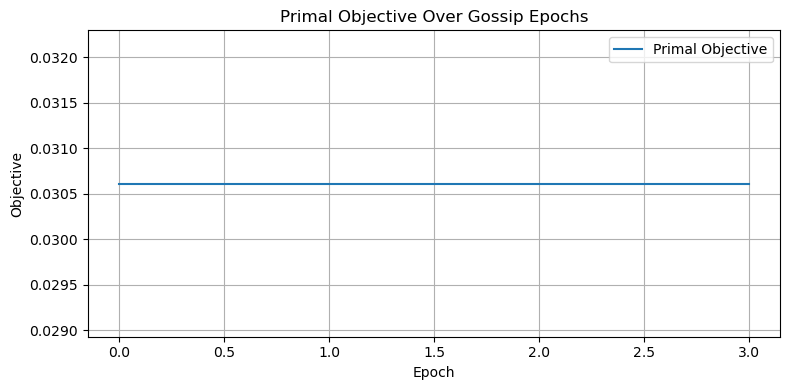

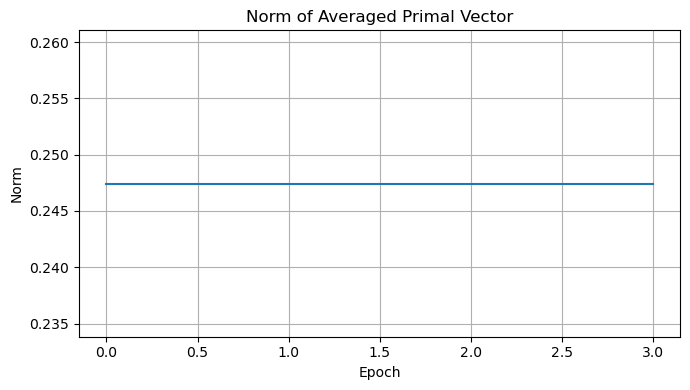

In [11]:

# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert labels to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Local dual solver with CVXPY
def solve_dual_local(X, y, C=1.0):
    n = X.shape[0]
    alpha = cp.Variable(n)
    K = X @ X.T
    K = (K + K.T) / 2  # Enforce symmetry
    Q = np.outer(y, y) * K
    Q_psd = cp.psd_wrap(Q)
    
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)
    
    return alpha.value

# 5. Convert dual alpha to primal w
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip (ring topology)
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop with CVXPY dual solving per epoch
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

for epoch in range(epochs):
    alphas = []
    for i in range(num_nodes):
        alpha_i = solve_dual_local(X_parts[i], y_parts[i], C=1.0)
        alphas.append(alpha_i)
        w_nodes[i] = alpha_to_primal(alpha_i, X_parts[i], y_parts[i])

    # Gossip step
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes

    # Evaluate primal objective
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

# 8. Test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plotting results
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()

Round 00 | Primal=118.7279 | ||v_avg||=0.2474
Round 01 | Primal=118.7279 | ||v_avg||=0.2474
Round 02 | Primal=118.7279 | ||v_avg||=0.2474
Round 03 | Primal=118.7279 | ||v_avg||=0.2474
Round 04 | Primal=118.7279 | ||v_avg||=0.2474
Round 05 | Primal=118.7279 | ||v_avg||=0.2474
Test Accuracy: 0.9993


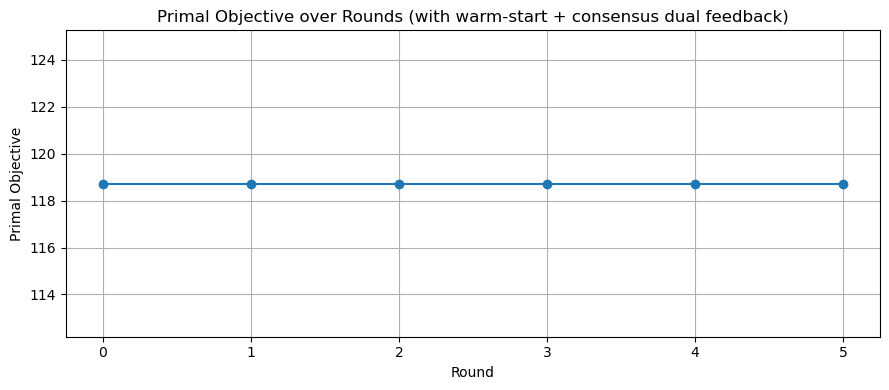

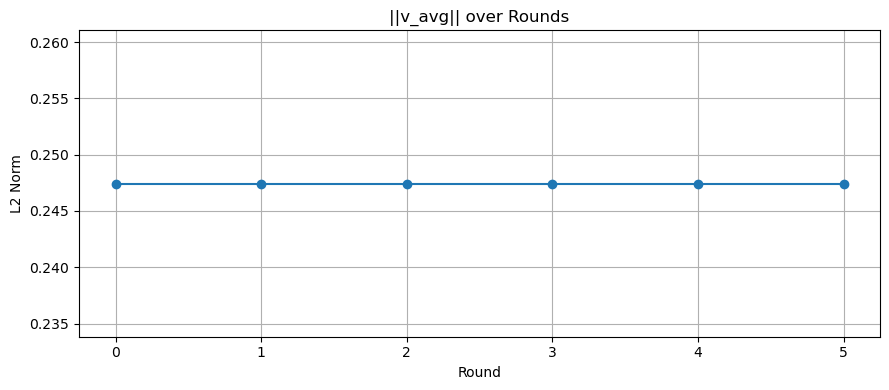

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import cvxpy as cp

# -----------------------------
# Data: MNIST 0 vs 1
# -----------------------------
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2*y - 1  # {-1,+1}

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Optional: subsample for speed (uncomment if needed)
# X, y = X[:8000], y[:8000]

# -----------------------------
# Partition across nodes
# -----------------------------
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)
d = X.shape[1]  # 784

# -----------------------------
# Local dual SVM (CVXPY) with warm-start
# -----------------------------
def solve_dual_local_warm(Xi, yi, C=1.0, alpha_init=None):
    n = Xi.shape[0]
    alpha = cp.Variable(n)

    K = Xi @ Xi.T
    K = 0.5*(K + K.T) + 1e-6*np.eye(n)   # symmetric + numeric PSD
    Q = np.outer(yi, yi) * K
    Q_psd = cp.psd_wrap(Q)

    obj = cp.Maximize(cp.sum(alpha) - 0.5*cp.quad_form(alpha, Q_psd))
    cons = [alpha >= 0, alpha <= C]
    prob = cp.Problem(obj, cons)

    # Warm-start
    if alpha_init is not None and len(alpha_init) == n:
        alpha.value = alpha_init

    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    # Fallback if OSQP not available
    if alpha.value is None:
        prob.solve(solver=cp.SCS, warm_start=True, verbose=False)
    return np.zeros(n) if alpha.value is None else alpha.value

def alpha_to_w(alpha, X, y):
    # w = sum_i alpha_i y_i x_i
    return (alpha * y) @ X

# -----------------------------
# Ring topology helpers
# -----------------------------
def ring_neighbors(j, N):
    return [(j-1) % N, (j+1) % N]

def gossip_ring(v_list):
    # Average with self + neighbors (Metropolis-like, simple 1/3)
    N = len(v_list)
    new_list = []
    for j in range(N):
        prev, nxt = ring_neighbors(j, N)
        new_list.append((v_list[prev] + v_list[j] + v_list[nxt]) / 3.0)
    return new_list

# -----------------------------
# Training (Primal-Dual with consensus dual feedback)
# -----------------------------
epochs = 6
C = 1.0            # SVM box constraint
rho = 0.05         # primal feedback step from consensus dual
eta = 0.2          # Step-18 dual step for consensus (α_cons)
w_nodes  = [np.zeros(d) for _ in range(num_nodes)]  # local primal (from SVM dual)
v_nodes  = [np.zeros(d) for _ in range(num_nodes)]  # primal with dual feedback
alpha_svm  = [np.zeros(len(y_parts[j])) for j in range(num_nodes)]  # warm-starts for CVX
alpha_cons = [np.zeros(d) for _ in range(num_nodes)]                 # consensus dual (Step 18)

primal_vals, wnorm_vals = [], []

for t in range(epochs):
    # (1) Local SVM dual solve (warm-start) → w_j
    for j in range(num_nodes):
        alpha_svm[j] = solve_dual_local_warm(X_parts[j], y_parts[j], C=C, alpha_init=alpha_svm[j])
        w_nodes[j]   = alpha_to_w(alpha_svm[j], X_parts[j], y_parts[j])

    # (2) Primal feedback from consensus dual: v_j = w_j - rho * alpha_cons_j
    for j in range(num_nodes):
        v_nodes[j] = w_nodes[j] - rho * alpha_cons[j]

    # (3) Gossip (mix) primal v across ring
    v_nodes = gossip_ring(v_nodes)

    # (4) Step-18 consensus dual update:
    #     alpha_cons_j <- alpha_cons_j + (eta/2) * sum_{i in N(j)} (v_j - v_i)
    new_alpha_cons = []
    for j in range(num_nodes):
        nbrs = ring_neighbors(j, num_nodes)
        sum_diff = np.zeros(d)
        for i in nbrs:
            sum_diff += (v_nodes[j] - v_nodes[i])
        new_alpha_cons.append(alpha_cons[j] + 0.5 * eta * sum_diff)
    alpha_cons = new_alpha_cons

    # (5) Monitoring on the whole (central) X,y using avg(v) as global model
    v_avg = sum(v_nodes) / num_nodes
    hinge = np.maximum(0, 1 - y * (X @ v_avg))
    primal = 0.5 * np.dot(v_avg, v_avg) + np.sum(hinge)
    primal_vals.append(primal)
    wnorm_vals.append(np.linalg.norm(v_avg))
    print(f"Round {t:02d} | Primal={primal:.4f} | ||v_avg||={np.linalg.norm(v_avg):.4f}")

# -----------------------------
# Evaluation
# -----------------------------
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = np.sign(X_test @ v_avg)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(9,4))
plt.plot(primal_vals, marker='o')
plt.title("Primal Objective over Rounds (with warm-start + consensus dual feedback)")
plt.xlabel("Round")
plt.ylabel("Primal Objective")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(wnorm_vals, marker='o')
plt.title("||v_avg|| over Rounds")
plt.xlabel("Round")
plt.ylabel("L2 Norm")
plt.grid(True)
plt.tight_layout()
plt.show()

Round 00 | Primal=610.6595 | ||w_avg||=0.1425
Round 01 | Primal=584.2701 | ||w_avg||=0.1445
Round 02 | Primal=583.4431 | ||w_avg||=0.1445
Round 03 | Primal=583.3346 | ||w_avg||=0.1445
Round 04 | Primal=583.3240 | ||w_avg||=0.1445
Round 05 | Primal=583.3227 | ||w_avg||=0.1445
Test Accuracy: 0.9986


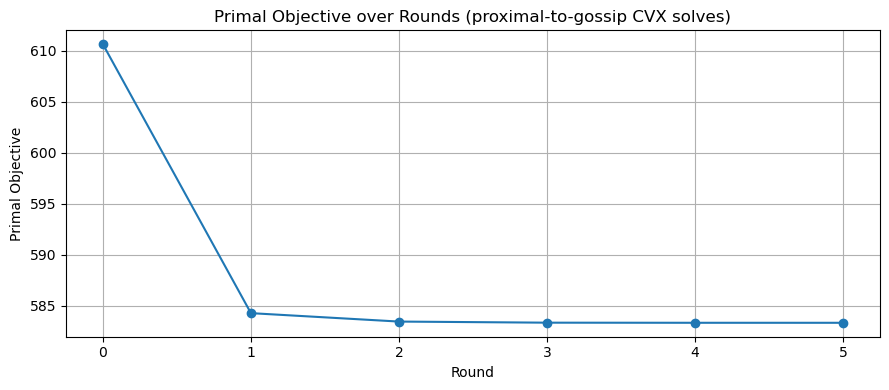

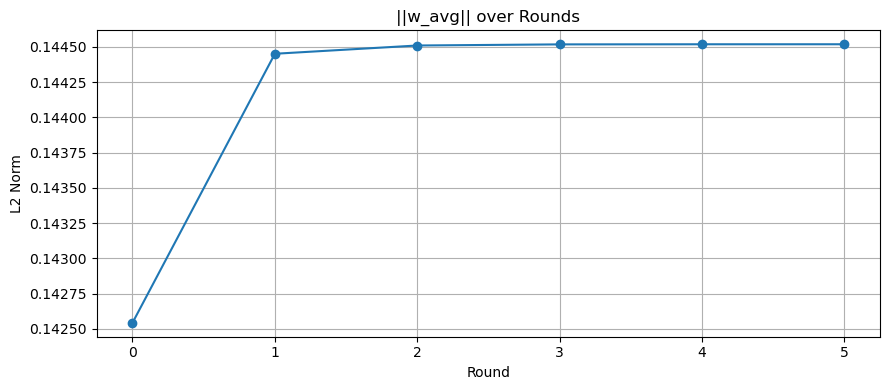

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import cvxpy as cp

# 1) Data: MNIST 0 vs 1
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2*y - 1  # {-1,+1}

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Optional: subsample for speed if needed
# X, y = X[:8000], y[:8000]

# 2) Partition across nodes
num_nodes = 100
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)
d = X.shape[1]

# 3) Local primal SVM with proximal term to v_target
def solve_primal_prox(Xi, yi, C=1.0, mu=0.1, v_target=None,
                      w_init=None, b_init=None, xi_init=None):
    n, d = Xi.shape
    w = cp.Variable(d)
    b = cp.Variable()
    xi = cp.Variable(n, nonneg=True)

    if v_target is None:
        v_target = np.zeros(d)

    # Hinge constraints
    constraints = [cp.multiply(yi, Xi @ w + b) >= 1 - xi]

    # Objective: 0.5||w||^2 + C*sum(xi) + (mu/2)||w - v_target||^2
    obj = 0.5*cp.sum_squares(w) + C*cp.sum(xi) + 0.5*mu*cp.sum_squares(w - v_target)
    prob = cp.Problem(cp.Minimize(obj), constraints)

    # Warm-start
    if w_init is not None: w.value = w_init
    if b_init is not None: b.value = b_init
    if xi_init is not None and len(xi_init) == n: xi.value = xi_init

    # OSQP is good for QP; fall back to SCS if needed
    try:
        prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        prob.solve(solver=cp.SCS, warm_start=True, verbose=False)

    # If solver failed, return zeros gracefully
    if w.value is None:
        return np.zeros(d), 0.0, np.zeros(n)

    return w.value, float(b.value), xi.value

# 4) Gossip (ring)
def ring_neighbors(j, N):
    return [(j-1) % N, (j+1) % N]

def gossip_ring(vecs):
    N = len(vecs)
    out = []
    for j in range(N):
        p, n = ring_neighbors(j, N)
        out.append((vecs[p] + vecs[j] + vecs[n]) / 3.0)
    return out

# 5) Training loop (iterative, linked rounds)
epochs = 6
C = 1.0      # hinge penalty
mu = 0.2     # consensus strength (increase to tighten consensus)
w_nodes = [np.zeros(d) for _ in range(num_nodes)]
b_nodes = [0.0 for _ in range(num_nodes)]
xi_nodes = [np.zeros(len(y_parts[j])) for j in range(num_nodes)]
v_targets = [np.zeros(d) for _ in range(num_nodes)]  # start with zeros

primal_vals = []
norm_vals = []

for t in range(epochs):
    # Local solves with proximal-to-gossip target and warm-start from last w,b,xi
    for j in range(num_nodes):
        w_j, b_j, xi_j = solve_primal_prox(
            X_parts[j], y_parts[j],
            C=C, mu=mu, v_target=v_targets[j],
            w_init=w_nodes[j], b_init=b_nodes[j], xi_init=xi_nodes[j]
        )
        w_nodes[j], b_nodes[j], xi_nodes[j] = w_j, b_j, xi_j

    # Build new gossip targets from current w's
    v_targets = gossip_ring(w_nodes)

    # Monitor global primal on averaged model (for visibility)
    w_avg = sum(w_nodes) / num_nodes
    hinge = np.maximum(0, 1 - y * (X @ w_avg))
    primal = 0.5*np.dot(w_avg, w_avg) + C*np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))
    print(f"Round {t:02d} | Primal={primal:.4f} | ||w_avg||={np.linalg.norm(w_avg):.4f}")

# 6) Evaluation
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = np.sign(X_test @ w_avg)  # (no bias term in global avg; add if you want)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 7) Plots
plt.figure(figsize=(9,4))
plt.plot(primal_vals, marker='o')
plt.title("Primal Objective over Rounds (proximal-to-gossip CVX solves)")
plt.xlabel("Round")
plt.ylabel("Primal Objective")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(norm_vals, marker='o')
plt.title("||w_avg|| over Rounds")
plt.xlabel("Round")
plt.ylabel("L2 Norm")
plt.grid(True)
plt.tight_layout()
plt.show()